# ECG Arrhythmia Classification
# Model Inference Notebook

# Importing Libraries

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model

print("="*50)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("="*50)
print("Libraries Imported Successfully ✅")

TensorFlow Version : 2.16.2
NumPy Version      : 1.24.3
Libraries Imported Successfully ✅


# Load Trained Model

In [ ]:


model = load_model("../models/ecg_arrhythmia_cnn.keras")

print("✅ Model Loaded Successfully")

model.summary()

✅ Model Loaded Successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 474,379 (1.81 MB)

 Trainable params: 157,827 (616.51 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 315,656 (1.20 MB)

In [ ]:
# Load Test Dataset

In [ ]:


X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_test Shape : (16482, 200)
y_test Shape : (16482,)


# Class Mapping

In [ ]:

class_names = {

    0: "Atrial Beat (A)",

    1: "Normal Beat (N)",

    2: "Ventricular Beat (V)"

}

print(class_names)

{0: 'Atrial Beat (A)', 1: 'Normal Beat (N)', 2: 'Ventricular Beat (V)'}


# Select One ECG Beat

In [ ]:

sample_index = 100

sample = X_test[sample_index]

true_label = y_test[sample_index]

print("Sample Shape :", sample.shape)
print("True Label :", class_names[true_label])

Sample Shape : (200,)
True Label : Normal Beat (N)


# Plot ECG Beat

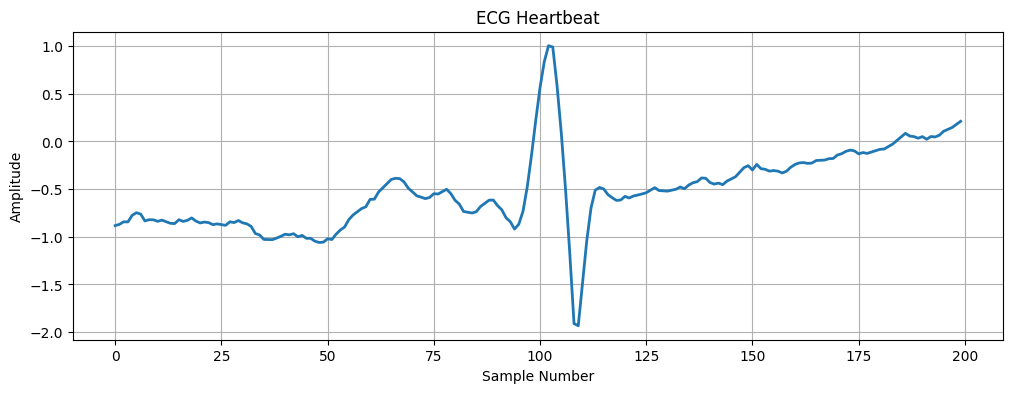

In [ ]:

plt.figure(figsize=(12,4))

plt.plot(sample, linewidth=2)

plt.title("ECG Heartbeat")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

# Prepare Sample

In [ ]:


sample_input = sample.reshape(1,200,1)

print(sample_input.shape)

(1, 200, 1)


# Model Prediction

In [ ]:

prediction = model.predict(sample_input)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

print("Prediction :", class_names[predicted_class])

print("Confidence :", round(confidence*100,2),"%")

print()

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Prediction : Normal Beat (N)
Confidence : 99.14 %

[[8.5659530e-03 9.9143410e-01 2.9344062e-11]]


# Prediction Summary

In [ ]:


print("="*50)

print("Actual Class    :", class_names[true_label])

print("Predicted Class :", class_names[predicted_class])

print("Confidence      :", round(confidence*100,2),"%")

print("="*50)

Actual Class    : Normal Beat (N)
Predicted Class : Normal Beat (N)
Confidence      : 99.14 %


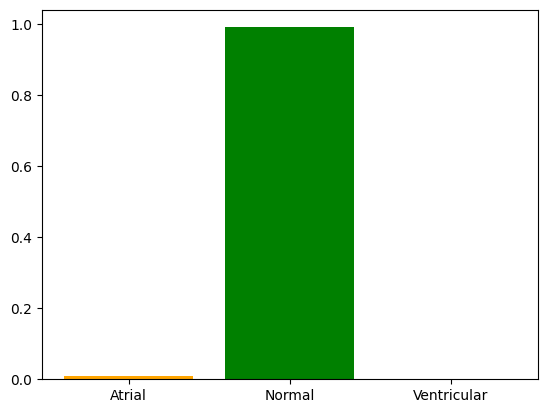

In [14]:
colors = ["orange","green","red"]

bars = plt.bar(
    labels,
    prediction[0],
    color=colors
)